# 'Python for Research' Program Session 4

**Written By: Joseph Yeung**

*Note, please do not distribute any of these materials without expressed consent from Joseph Yeung!*

Over halfway done with the lectures now! Don't forget to hold tight onto all of the things we learned previously. Feel free to refer back to those notebooks whenever you need.

## The Goal:

As you hopefully saw last week, the easy access to a very wide variety of packages is what makes Python so powerful. So, let's talk more packages.

In this session, we will build off the previous lecture by introducing more of Python's most popular packages, especially for a scientist. 

1. Scipy - Integration
2. Scipy - Optimization
3. Scipy - Other
4. Pandas
5. Kepler's Third Law

## 1. Scipy - Integration

The majority of today will be focused on an incredibly powerful package - scipy. The "sci" in scipy stands for science or scientific, so it will undoubtedly be important in future physics research. Let's start with the import.

In [1]:
import scipy

Yep, that's it. While we're at it, let's import some trusty friends from last lecture. As you'll see, scipy plays really well with numpy and matplotlib. In fact, scipy is essentially a computational extension of numpy. In the current versions, actually, many of the tools exist in both numpy and scipy.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Alright, let's see some of the magic.

### Integration

Yes, today we will be doing a little calculus (single and multivariable, but you don't need to be too fluent in it to follow along). Proceed at your own risk!

Let's first deal with every physicist's worst nightmare - integration.

With scipy, however, integration becomes much better! Let's start with a simple problem.

\begin{equation}
\int_0^5 x^3 dx
\end{equation}

We'll need to import a more specific part of scipy:

In [3]:
import scipy.integrate as integrate

First, let's define the function.

In [5]:
def cubic(x):
    return x**3

Next, all we need to do is use integrate.quad(function, lower_bound, upper_bound). That's really it.

In [7]:
result = integrate.quad(cubic, 0, 5)
result

(156.25000000000003, 1.7347234759768075e-12)

What do these two values mean? Well, the first value is the numerical answer. You can go to your favorite integration calculator and check that the exact answer is indeed 156.25. The second number is the upper bound on the error. As with any numerical method, don't expect precise results, just very good approximations. This upper bound on error helps us quantify the numerical inaccuracy.

What does the "quad" in integrate.quad mean? It means integrate by "quadratures," a general numerical integration technique. We could have picked something else like Romberg integration for example. If these words mean nothing to you, don't worry about it! This isn't a computational methods class, so we won't get bogged down by these words.

Let's do a slightly more general problem. Let's consider the most general form of a cubic.

\begin{equation}
\int_\alpha^\beta (ax^3 + bx^2 + cx + d) dx
\end{equation}

where a, b, c, and d are constants defining the cubic. In code,

In [8]:
def cubic(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

Now to integrate this, we add another argument, called args=(), where the tuple includes the specified parameters. For example, let's say we want to compute the same integral as previously.

\begin{equation}
\int_0^5 x^3 dx
\end{equation}

Then, we have $a=1, b=c=d=0$.

In [10]:
a, b, c, d = 1, 0, 0, 0
integrate.quad(cubic, 0, 5, args=(a, b, c, d))

(156.25000000000003, 1.7347234759768075e-12)

As expected, the same result as previously. What if now, we have something crazier.

\begin{equation}
\int_{-3.4}^{2.3} (1.9x^3 + 2.3x + 9.8) dx
\end{equation}

To do this by hand, well, good luck. But with scipy, it's as easy as just changing the parameter values.

In [17]:
a, b, c, d = 1.9, 0, 2.3, 9.8
integrate.quad(cubic, -3.4, 2.3, args=(a, b, c, d))

(-1.5340124999999862, 1.1641854214163023e-12)

Hopefully it's clear now why it's often better to define functions more generally. If we plan on integrating it often but with different parameters, we can just specify the parameters upon each integration, without needing to redefine the function everytime.

### Example: Gaussian

Here's an even more complicated example, which emphasizes why scipy/Python is so much more powerful than a basic calculator. Consider, the famous Gaussian function.

\begin{equation}
Ne^{-ax^2}
\end{equation}
where N and a are constants. This function is famous for a couple reasons. One reason is that it corresponds to the Gaussian/Normal distribution in statistics. This probably doesn't mean a lot for many of you right now (but know that this shows up all the time in physics, especially in wave mechanics and quantum mechanics!).

Another reason it's famous is that it's very tricky to integrate! Consider the following integral.

\begin{equation}
\int_{-\infty}^{\infty}e^{-x^2}dx = \sqrt{\pi}
\end{equation}

Yes, that's right, this integral computes to the square root of $\pi$. 

If you haven't taken a class on multivariable calculus, good luck doing this by hand. But once again, with scipy, we don't need to do it by hand. Let's take a look.

In [19]:
def gaussian(x, N, a):
    return N * np.exp(-a * x**2)

By the way, np.exp() is equivalent to math.e. There also exists np.pi, np.cos(), np.sin(), etc. So yes, the math package is kind of useless to us...

Let's see what this function even looks like. Recall how to graph from last time. Of course here, $N=a=1$.

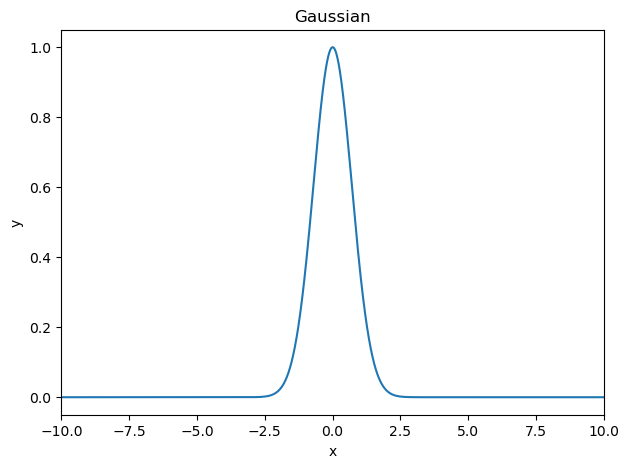

In [28]:
x = np.linspace(-100, 100, 100000)
y = gaussian(x, 1, 1)

plt.figure(figsize=(7, 5))
plt.plot(x, y)
plt.title("Gaussian")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-10, 10)
plt.show()

Now, to compute the integral, recall from last time that we can't actually use infinities numerically. For reasons I won't go into too much detail today, using really large bounds like $\pm1000000$ will actually give us totally the wrong answer. This is not a big deal though. Look at the graph above and notice that the meat of the area is in a very small region around 0, so we don't need very large bounds anyways.

Let me first show you how large bounds messes up.

In [29]:
N, a = 1, 1
integrate.quad(gaussian, -1000000, 1000000, args=(N, a))

(0.0, 0.0)

Yeah, it's definitely not 0...

Let's do it with smaller bounds.

In [30]:
N, a = 1, 1
integrate.quad(gaussian, -15, 15, args=(N, a))

(1.772453850905516, 8.476539755481946e-11)

Compare this to the exact value $\sqrt{\pi}$.

In [31]:
print(np.sqrt(np.pi))

1.7724538509055159


The answers are extremely similar!

What are the general lessons to be learned here? 

1. Scipy and Python make complicated problems easy! Even without knowing the theory to solve this integral exactly, we can use numerical tools like scipy to get extremely accurate approxmations.
2. Even though we don't know exactly why really large bounds caused a problem, we can do sanity checks. Just looking at the graph, we know the area shouldn't be zero. Often times in computational problems, one must vary parameters to see what works and what doesn't (this is even true in machine learning!). For this integration problem, we needed to vary the bounds of integration. Long story short, always play around with numerical parameters to see what sticks

Let's do an even trickier integral.
\begin{equation}
\int_{-1}^{1.5}e^{-3x^2}dx
\end{equation}

I guarantee you that this integral is not solvable by hand (only bounds of infinity make this solvable analytically). This is actually a special type of function called the Gaussian Error function. Luckily, we have scipy!

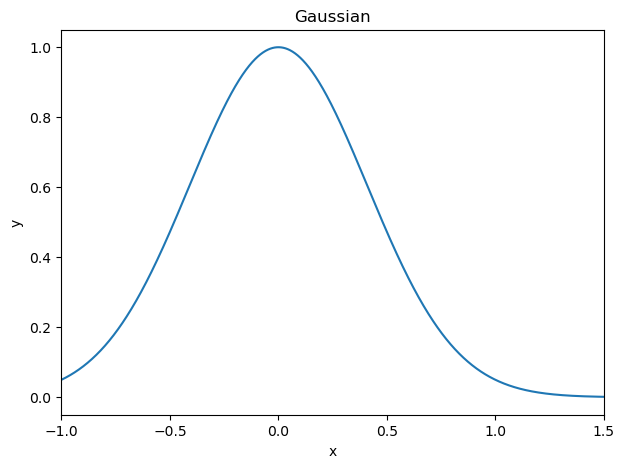

In [34]:
x = np.linspace(-100, 100, 100000)
y = gaussian(x, 1, 3)

plt.figure(figsize=(7, 5))
plt.plot(x, y)
plt.title("Gaussian")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-1, 1.5)
plt.show()

In [32]:
N, a = 1, 3
integrate.quad(gaussian, -1, 1.5, args=(N, a))

(1.0158848500276592, 1.1278587588067594e-14)

Once again, go to your favorite integral calculator website to see that this result is shockingly accurate!

Now, I took extra time to discuss this example with single-variable integration, but hopefully it showcased some general principles about numerical/computational techniques. Let's go on to bigger and better things.

### Double and Triple Integrals

I won't go into too much detail, as I'm sure many of you haven't yet seen higher order integration, but I will show you some examples.

Suppose we want to integrate the following double integral:

\begin{equation}
\int_0^1 \int_0^1 xy \:dxdy
\end{equation}

In [40]:
def func(x, y):
    return x * y

area = integrate.nquad(func, [[0, 1], [0, 1]])
area

(0.25, 5.539061329123428e-15)

What if we have general bounds?

\begin{equation}
\int_0^1 \int_0^{y^2} xy \:dxdy
\end{equation}

In [41]:
def func(x, y):
    return x * y

def ybound():
    return [0, 1]

def xbound(y):
    return [0, y**2]

area = integrate.nquad(func, [xbound, ybound])
area

(0.08333333333333334, 5.4911073236987565e-15)

Notice how now the bounds I input are functions themselves. I won't go through it now, but you can see how this generalizes to triple integrals and more.

#### Example

Compute the following integral numerically:

\begin{equation}
\int_0^{2\pi} \int_0^{3} r \:drd\theta
\end{equation}

For those that have taken multivariable calculus, you can see that this is equivalent to the area of a circle with radius 3. Compute the area of a circle with radius 3 and check that they are, roughly, the same.

In [ ]:
# First, define the function and bounds

# Next, compute the integral

In [46]:
# Finally, check this against the area of a circle with radius 3.

## 2. Scipy - Optimization

For our next trick, let's channel our inner UChicago Economics major energy: optimization.

I will start by saying the task of numerical optimization is an extremely deep and interesting subject that we of course will not be going into full detail. Instead, the goal is to just implement a scipy optimization.

In [47]:
from scipy.optimize import minimize

Scipy really only has an option to minimize. Should we want to maximize, all we have to do is add a negative sign in front of the function!

Let's examine a very interesting 1-D function, the Leonard-Jones potential.

\begin{equation}
V(r) = 4\epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^{6} \right]
\end{equation}

Here, $\epsilon$ and $\sigma$ are parameters.

Let's first graph this beast.

In [79]:
def lennard_jones(r, eps, sig):
    return 4 * eps * ((sig / r)**12 - (sig / r)**6)

To make the problem more well defined, let's just say $\epsilon = 2, \sigma = 1$. Then,

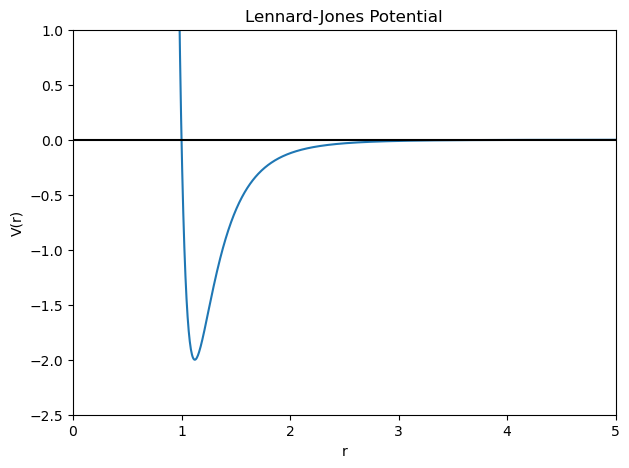

In [80]:
eps, sig = 2, 1
r = np.linspace(0.0001, 5, 1000)
v = lennard_jones(r, eps, sig)

plt.figure(figsize=(7, 5))
plt.plot(r, v)
plt.title("Lennard-Jones Potential")
plt.xlabel("r")
plt.ylabel("V(r)")
plt.ylim(-2.5, 1)
plt.xlim(0, 5)
plt.hlines(0, -5, 10, color='black')
plt.show()

Let's now try to minimize this function. To do this, we'll need to provide an x0 value, aka a starting guess. Just looking at the graph, the minimum seems quite close to 1, so we might as well guess that.

In [81]:
x0 = [1]
res = minimize(lennard_jones, x0, args=(eps, sig))
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.999999999999954
        x: [ 1.122e+00]
      nit: 4
      jac: [ 4.083e-06]
 hess_inv: [[ 8.732e-03]]
     nfev: 34
     njev: 17

Scipy gives us a very long description of the process, but really we're interested in the x value.

In [82]:
print(res.x)

[1.12246208]


This is the minimum it find. To check the validity, why don't we graph this point and see if it looks right.

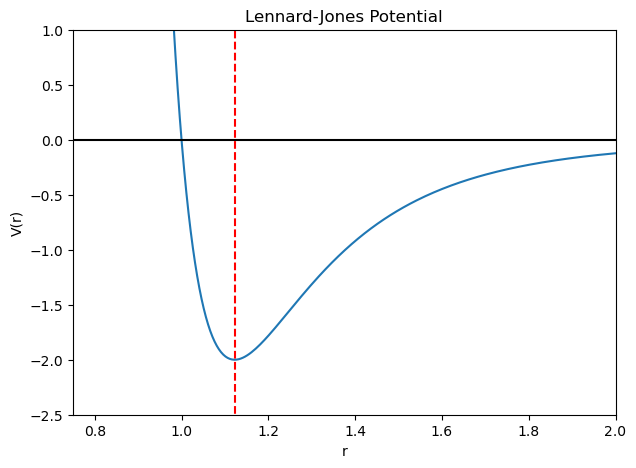

In [83]:
plt.figure(figsize=(7, 5))
plt.plot(r, v)
plt.title("Lennard-Jones Potential")
plt.xlabel("r")
plt.ylabel("V(r)")
plt.ylim(-2.5, 1)
plt.xlim(0.75, 2)
plt.hlines(0, -5, 10, color='black')
plt.vlines(res.x, -10, 10, color='red', linestyle='--') # this is the key part!
plt.show()

Looks pretty good to me! 

There are many other details to the scipy.optimize.minimize function. For example, we could specifiy our maximum allowed error tolerance. Once again, it is hard to go into this without more background in computational techniques, so I won't do it here. Just know that plenty of examples and documentation exist should you ever need to understand this.

### Multivariable Functions

We can also optimize multivariable functions. Consider the simple function,

\begin{equation}
f(x, y) = (x-2)^2 + 3(y+2)^2 - 5
\end{equation}

We follow very similar steps.

In [89]:
def func(x):
    assert len(x) == 2
    return (x[0]-2)**2 + 3 * (x[1]+2)**2 - 5

x0 = [0, 0]
res = minimize(func, x0)
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -4.999999999998624
        x: [ 2.000e+00 -2.000e+00]
      nit: 7
      jac: [ 7.749e-07  3.874e-06]
 hess_inv: [[ 5.011e-01  1.826e-03]
            [ 1.826e-03  1.696e-01]]
     nfev: 24
     njev: 8

Importantly, notice how my function is one-variable, but that one-variable is a np.array of length 2. In other words, it's really a two-variable function in disguise. You could think of it like this:

\begin{equation}
f(\vec{x}) = f(x, y)
\end{equation}

Now, let's test our result. Graphing in 2D is beyond the scope of these lectures, so let's instead try an extremely crude test. We'll just try out some values around the minimum and see if they're greater than the minimum.

In [91]:
test = np.array([
    res.x, # min
    [2, -3],
    [2, -1],
    [1, -2],
    [3, -2],
])
print(func(test.T))

[-5. -2. -2. -4. -4.]


As expected, the lowest value is of course the at the minimum calculated by scipy. Excellent.

### Example - Acceleration Due to Gravitation

Let's try one last meaningful example. We can try to approximate the gravitational acceleration constant by simply dropping items at a certain height and measuring the fall time. Suppose an object is (roughly) in free fall such that the only force is non-relativistic gravity.

\begin{equation}
F = mg = ma \\
 \\
a = g \\
a = g = \frac{height}{time^2}
\end{equation}

Thus, if we fix some height, and measure the free-fall times, we can get data points for g. Let's do that first (if you're looking at this on your own, grab a meterstick, drop a pencil from the top, and measure the times and enter into the array below).

In [107]:
t = np.array([]) # input your times into this array!
h = 1 # in meters
g_data = h / t**2

Let's plot these results first.

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(np.arange(0, len(t)) + 1, g_data)
plt.title("g_data")
plt.xlabel("trial number")
plt.ylabel("g")
plt.show()

Now to the statistics. There is a special type of statistic called the $\chi^2$ statistic. It is defined as follows:

\begin{equation}
\chi^2 = \sum_i \frac{(O_i - E)^2}{E}
\end{equation}

where $O_i$ is each data point (indexed with i) and $E$ is the expected value. In very crude terms (don't come at me stats majors), the expected value $E$ that minimizes the $\chi^2$ statistic is a good approximation for the actual value. Thus, for our problem, if we can find the value of $E=g$ that minimizes the $\chi^2$, this is a good approximation for the gravitational acceleration.

In [109]:
def chi_squared(g, data):
    return np.sum((data - g)**2 / g)

In [ ]:
x0 = [10]
res = minimize(chi_squared, x0, args=(g_data))
res

Even better, there does exist a chi squared function built into scipy. We won't go into it today as it requires more stats knowledge, but know that it exists and feel free to look it up in your own time.

## 3. Scipy - Other

Scipy has many other cool functions to use! I'll go over a couple that I think are either interesting or useful.

### Linear Regression

This is a fancy way of saying "here are some data points; please draw a nice line through it." 

Regression analysis is once again a very complicated subject. However, the nice thing about all of these packages is you don't need to know the full details behind the magic. It just kind of does it all for you. While it's definitely worth it to take a more detailed statistics or computational methods class to better intuit these methods, know that Python and these powerful packages makes it really easy to jump right into research without having it all nailed!

Back to linear regressions. Let's return to the gravitational acceleration problem. Suppose I want to estimate g. I take a bunch of objects of different masses and I use a scale to calculate their weights (aka the force of gravity on the object by Newton's third law). 

\begin{equation}
F = mg
\end{equation}

By Newton's second law, we know there is a linear relation between force and mass. The constant of proportionality is then g.

Let's create some fake data that we can apply the linear regression to.

In [124]:
def fake_data(m):
    return m * 9.81 + np.random.normal(0, 10, len(m))

Now, some mass points (in kg):

In [125]:
m = np.linspace(1, 10, 20) + np.random.normal(0, 0.3, 20)
f = fake_data(m)

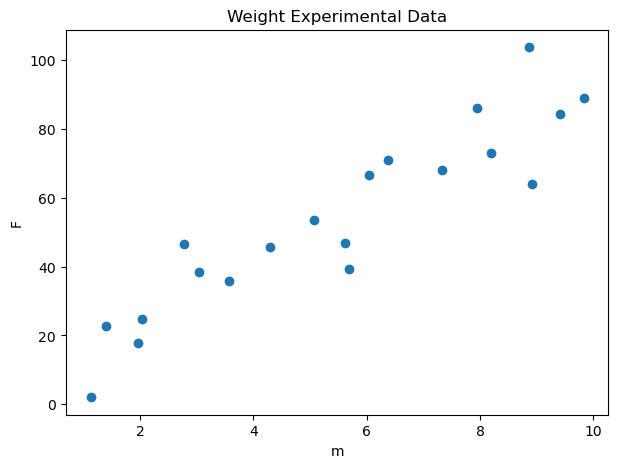

In [126]:
plt.figure(figsize=(7, 5))
plt.scatter(m, f)
plt.title("Weight Experimental Data")
plt.xlabel("m")
plt.ylabel("F")
plt.show()

As expected, the data looks roughly linear, but it's not exactly clear in the specifics. Let's run a linear regression to examine it more closely.

In [283]:
from scipy.stats import linregress

In [130]:
result = linregress(m, f)
result

LinregressResult(slope=8.657489178879045, intercept=6.593020868117591, rvalue=0.9230309115352853, pvalue=6.7932930971172185e-09, stderr=0.8505322071486996, intercept_stderr=5.22255384206267)

In [131]:
result.slope

8.657489178879045

It's really that simple! Just linregress(x, y). Let's plot this against the data and see how it looks.

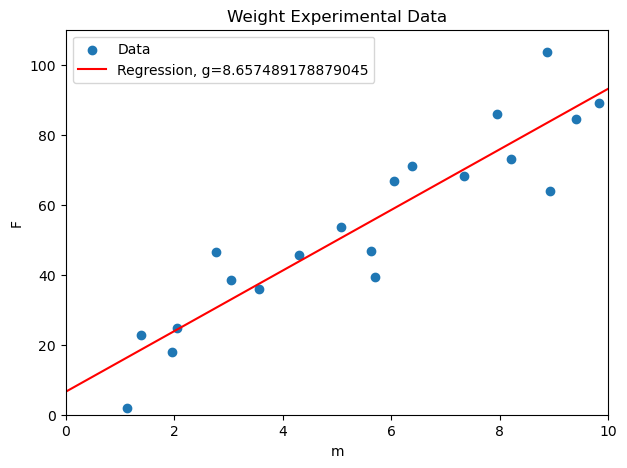

In [141]:
def regression(result, rng=[-50, 50]):
    # y = ax + b
    a = result.slope
    b = result.intercept
    x = np.linspace(rng[0], rng[1], 100)
    return x, a*x + b 

plt.figure(figsize=(7, 5))
plt.scatter(m, f, label='Data')
plt.title("Weight Experimental Data")
plt.xlabel("m")
plt.ylabel("F")
plt.xlim(0, 10)
plt.ylim(0, 110)

x, y = regression(result)
plt.plot(x, y, color='red', label='Regression, g={}'.format(result.slope))
plt.legend()
plt.show()

As you can see, the regression result is certainly not perfect, but it is quite nice considering the (fake) error in our data as well as the lack of data points. As we tighten up the error with better experimental procedure and increase the number of data points, we will start to approach 9.81.

By the way, if you have ever used the Google Collab notebook provided in the PHYS 131/141 labs, this is all they're doing! 

### Special Functions

*Note*: This section is advanced. I will not go into any detail.

Scipy also has a wide range of built in special functions. Here are some examples.

In [162]:
from scipy import special

#### Bessel Functions: jv()

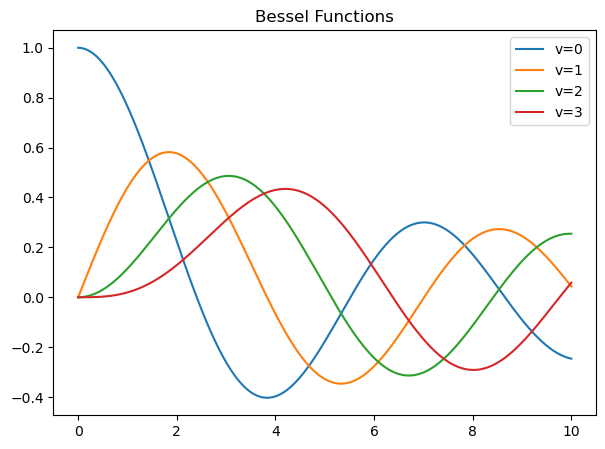

In [203]:
# Bessel Functions: J_v(z)
plt.figure(figsize=(7, 5))
x = np.linspace(0, 10, 1000)
for v in range(4):
    y = (special.jv(v, x))
    plt.plot(x, y, label='v={}'.format(v))
plt.legend()
plt.title('Bessel Functions')
plt.show()

#### Gamma Function: gamma()

In [196]:
print(special.gamma(6))
print(np.math.factorial(6-1))

120.0
120


#### Error Function: erf()

In [200]:
print(special.erf(1))

0.8427007929497148


#### Legendre Functions and Polynomials: lpmv()

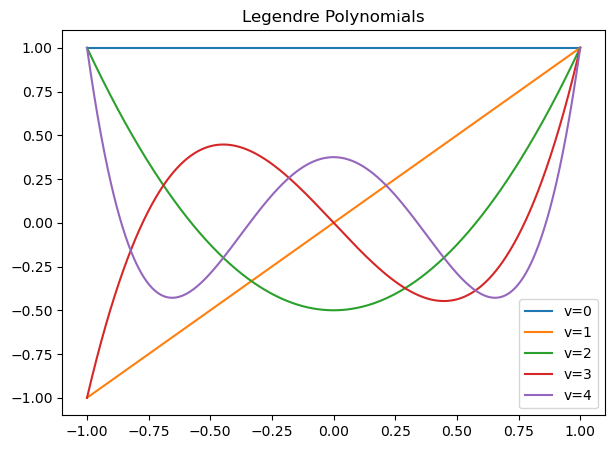

In [205]:
# Legendre Polynomials: P_v(x)
plt.figure(figsize=(7, 5))
x = np.linspace(-1, 1, 1000)
for v in range(5):
    y = (special.lpmv(0, v, x)) # here, m=0 for Legendre Polynomials; 
                                # m!=0 for general Legendre functions
    plt.plot(x, y, label='v={}'.format(v))
plt.legend()
plt.title('Legendre Polynomials')
plt.show()

#### Spherical Harmonics: sph_harm()

In [ ]:
# Spherical Harmonics: Y_n ^m (theta, phi)
# special.sph_harm(m, n, theta, phi)

## 4. Pandas

The final main package we will discuss is pandas. This package is commonly used for efficient data handling and analysis. Just like scipy, it has many properties that are similar to numpy. Let's see it in action.

In [3]:
import pandas as pd

The primary purpose of pandas is to organize and handle datasets. For now, let's create a simple dataset to play with.

In [246]:
names = ['electron', 'proton', 'neutron', 'photon']
mass = [0.511, 938, 940, 0]
spin = [1/2, 1/2, 1/2, 0]
charge = [-1, 1, 0, 0]
classification = ['fermion', 'fermion', 'fermion', 'boson']

particles = {
    'names': names,
    'mass (MeV)': mass,
    'spin': spin,
    'charge': charge,
    'classification': classification
}

The main type of object we'll work with in pandas is called a "dataframe." To convert this dictionary into a dataframe, we do the following:

In [247]:
particles = pd.DataFrame(particles)
particles

,names,mass (MeV),spin,charge,classification
0,electron,0.511,0.5,-1,fermion
1,proton,938.000,0.5,1,fermion
2,neutron,940.000,0.5,0,fermion
3,photon,0.000,0.0,0,boson


Look at how nicely it displays all of the data! Let's look at some properties and manipulations of these dataframes.

### Dataframes

Suppose we just want to see our column labels. Just like we could easily obtain dictionary keys, we can do the same with dataframes.

In [248]:
particles.columns

Index(['names', 'mass (MeV)', 'spin', 'charge', 'classification'], dtype='object')

We can also easily see how many rows are in the dataframe. It's obvious in this example, but it might not be so obvious for some really large dataframe.

In [249]:
len(particles)

4

We can also individually extract columns of the dataframe. 

In [250]:
m = particles['mass (MeV)']
print(m)

0      0.511
1    938.000
2    940.000
3      0.000
Name: mass (MeV), dtype: float64


In a lot of ways, these columns work extremely similar to numpy arrays, as in we can easily apply elementwise operations to them.

Let's say I live in an alternate reality where every particle is twice as heavy! I can easily just apply this operation.

In [251]:
m2 = 2 * m
print(m2)

0       1.022
1    1876.000
2    1880.000
3       0.000
Name: mass (MeV), dtype: float64


Now, I can redefine the dataframe such that these are our new masses.

In [252]:
particles['mass (MeV)'] = m2
particles

,names,mass (MeV),spin,charge,classification
0,electron,1.022,0.5,-1,fermion
1,proton,1876.000,0.5,1,fermion
2,neutron,1880.000,0.5,0,fermion
3,photon,0.000,0.0,0,boson


For my sake, let's revert this back to our ordinary universe.

In [253]:
particles['mass (MeV)'] = m
particles

,names,mass (MeV),spin,charge,classification
0,electron,0.511,0.5,-1,fermion
1,proton,938.000,0.5,1,fermion
2,neutron,940.000,0.5,0,fermion
3,photon,0.000,0.0,0,boson


We can also very easily add columns.

In [254]:
particles['elementary'] = [True, False, False, True]
particles

,names,mass (MeV),spin,charge,classification,elementary
0,electron,0.511,0.5,-1,fermion,True
1,proton,938.000,0.5,1,fermion,False
2,neutron,940.000,0.5,0,fermion,False
3,photon,0.000,0.0,0,boson,True


Here, I have added an additional column labelling whether the particle is elementary or not. For those that are interested, protons and neutrons are actually composed of quarks, so they themselves are not elementary.

We can also add a row to the dataframe. The best way to do this, especially when adding multiple rows, is to concatenate two dataframes.

In [255]:
muon = {
    'names': ['muon'],
    'mass (MeV)': [106],
    'spin': [1/2],
    'charge': [-1],
    'classification': ['fermion'],
    'elementary': [True]
}

new_part = pd.concat([particles, pd.DataFrame(muon)], ignore_index=True)
new_part

,names,mass (MeV),spin,charge,classification,elementary
0,electron,0.511,0.5,-1,fermion,True
1,proton,938.000,0.5,1,fermion,False
2,neutron,940.000,0.5,0,fermion,False
3,photon,0.000,0.0,0,boson,True
4,muon,106.000,0.5,-1,fermion,True


### Reading CSV Data

Something particularly useful is that pandas can directly read csv data and convert it into a dataframe. Here, I have downloaded data from the TESS dataset (https://exoplanetarchive.ipac.caltech.edu/).

If you look at the csv, the first 34 rows have other information. We can easily skip these rows as shown below.

In [268]:
df = pd.read_csv('tess.csv', skiprows=34)
df

,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.0,0.0,0.0,0.0,0.0,...,-81.0,4.467,0.064,-0.096,0.9270 6,NaN,1087298.000,K00756.,1 Kepler-,28 d CONF
1,4230 48.141,51 15.347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.0,0.0,0.0,0.0,0.0,...,-81.0,4.467,0.064,-0.096,0.9270 6,NaN,1087298.000,K00756.,1 Kepler-,28 d CONF
3,4230 48.141,51 15.347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.0,0.0,0.0,0.0,0.0,...,-176.0,4.544,0.044,-0.176,0.8680,0.233,-0.078,297.004820,48.134129,15.436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2076,12257999,K02577.01,NaN,CANDIDATE,CANDIDATE,1.0,0.0,0.0,0.0,0.0,...,-503.0,2.982,0.273,-0.117,8.8410,1.492,-3.232,291.287720,50.909149,13.506
2077,6922203,K02578.01,NaN,CANDIDATE,CANDIDATE,1.0,0.0,0.0,0.0,0.0,...,-179.0,4.394,0.105,-0.195,1.0390,0.302,-0.139,281.260130,42.403290,14.847
2078,11752908,K02651.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.0,0.0,0.0,0.0,1.0,...,-184.0,4.623,0.032,-0.091,0.7140,0.114,-0.061,285.574920,49.960892,15.554
2079,7021681,K00255.01,Kepler-505 b,CONFIRMED,CANDIDATE,1.0,0.0,0.0,0.0,0.0,...,-83.0,4.746,0.042,-0.031,0.5110,0.036,-0.043,287.858120,42.542629,15.108


In [270]:
df.columns

Index(['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_sma', 'koi_sma_err1', 'koi_sma_err2', 'koi_teq',
       'koi_teq_err1', 'koi_teq_err2', 'koi_insol', 'koi_insol_err1',
       'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')

## 5. Kepler's Third Law

Notice that the above csv that we read is real exoplanet data. For those unfamiliar, exoplanet is short for "Extra-Solar Planet." Aka, it is any planet that is not within our solar system. Just as we'd expect, these planets obey the same laws of mechanics that we do in our local solar system. Why don't we put that to the test?

Recall that Kepler's Laws describe the nuanced nature of planetary motion around a host star. Kepler's Third Law specifically relates a planet's orbital period and semi-major axis. More on this in a second. For now, let's plot these two data points against each other.

Remember that dataframe columns work essentially like numpy arrays. Thus, we can plot them very easily.

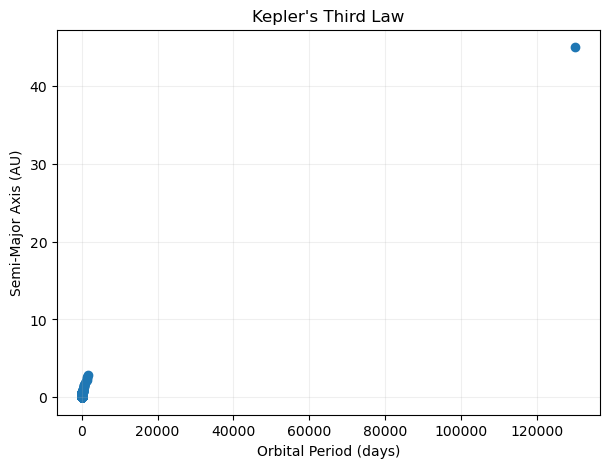

In [275]:
plt.figure(figsize=(7, 5))
plt.scatter(df['koi_period'], df['koi_sma'])
plt.grid(alpha = .2)
plt.xlabel('Orbital Period (days)')
plt.ylabel('Semi-Major Axis (AU)')
plt.title("Kepler's Third Law")
plt.show()

For better visualization of the data, let's get rid of the outlier point way in the top right corner.

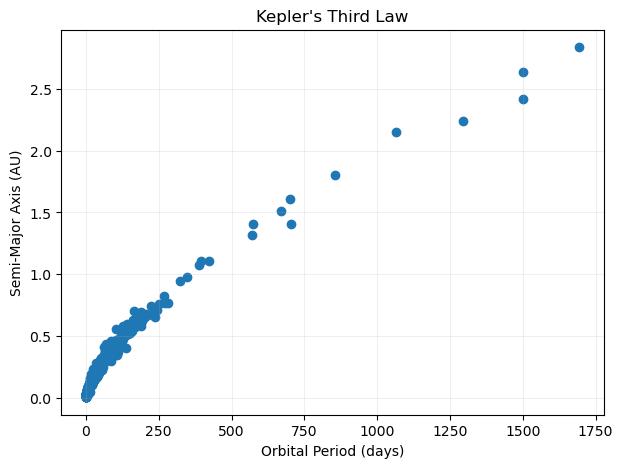

In [314]:
mask = df['koi_period'] < 20000

plt.figure(figsize=(7, 5))
plt.scatter(df['koi_period'][mask], df['koi_sma'][mask]) # notice the new mask applied
plt.grid(alpha = .2)
plt.xlabel('Orbital Period (days)')
plt.ylabel('Semi-Major Axis (AU)')
plt.title("Kepler's Third Law")
plt.show()

Let's see if the data truly follows Kepler's Third Law. Kepler's Third Law states a proportionality relationship between the square of the orbital period and the cube of the semi-major axis. In other words,

\begin{equation}
T^2 \propto a^3
\end{equation}
where $T$ is orbital period and $a$ is semi-major axis. To right this as an equality,

\begin{equation}
a = kT^{2/3}
\end{equation}
where $k$ is the constant of proportionality (which really won't matter here). 

We learned previously how to run a linear regression, but not a power law regression. Fortunately, we can use a trick. Notice what happens when we take the logarithm on both sides.

\begin{equation}
\log{(a)} = \log{(kT^{2/3})} = \log{(k)} + \frac{2}{3}\log{(T)}
\end{equation}

This is now a linear relationship. To make it more obvious, we can even redefine new variables,

\begin{equation}
a' = \frac{2}{3}T' + k'
\end{equation}

where $a' = \log{(a)}, T' = \log{(T)}, k' = \log{(k)}$. Now we can thus run the linear regression on the log of the dataset and we should expect the slope to be around $2/3$.

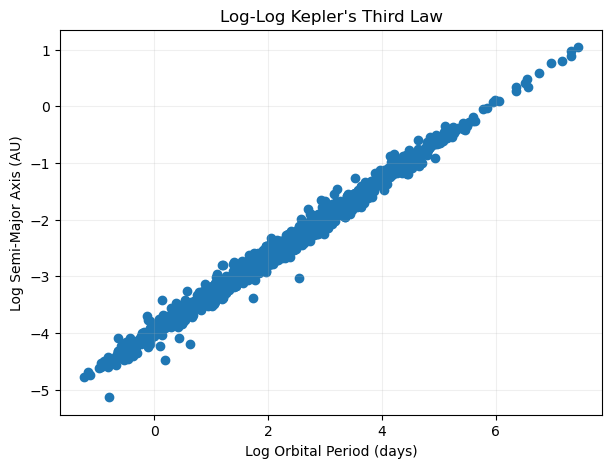

In [315]:
T = df['koi_period'][mask]
a = df['koi_sma'][mask]

T_prime = np.log(T)
a_prime = np.log(a)

plt.figure(figsize=(7, 5))
plt.scatter(T_prime, a_prime)
plt.grid(alpha = .2)
plt.xlabel('Log Orbital Period (days)')
plt.ylabel('Log Semi-Major Axis (AU)')
plt.title("Log-Log Kepler's Third Law")
plt.show()

Now to run the linear regression.

In [287]:
result = linregress(np.array(T_prime), np.array(a_prime))
result

LinregressResult(slope=nan, intercept=nan, rvalue=nan, pvalue=nan, stderr=nan, intercept_stderr=nan)

Huh, what happened. Well, it doesn't show in the graph obviously, but turns out there are some messed up data points in the data set. What is happening is that there is somewhere in the dataset that is becoming a 'nan' point. You could think of this as just like a null data point. Maybe the catalog lacks data for this point. Regardless, you can use np.isnan() on an array to see if any of the values are nan.

In [311]:
print(np.any(np.isnan(T_prime)))
print(np.any(np.isnan(a_prime)))

False
True


There's our suspect. So, we can simply create a mask that filters out these values.

In [292]:
mask = ~np.isnan(T_prime) & ~np.isnan(a_prime)
result = linregress(T_prime[mask], a_prime[mask])
result

LinregressResult(slope=0.6710769367155566, intercept=-3.9716970222300363, rvalue=0.9950885637464667, pvalue=0.0, stderr=0.001475853022621014, intercept_stderr=0.003877327906356237)

Let's plot this now.

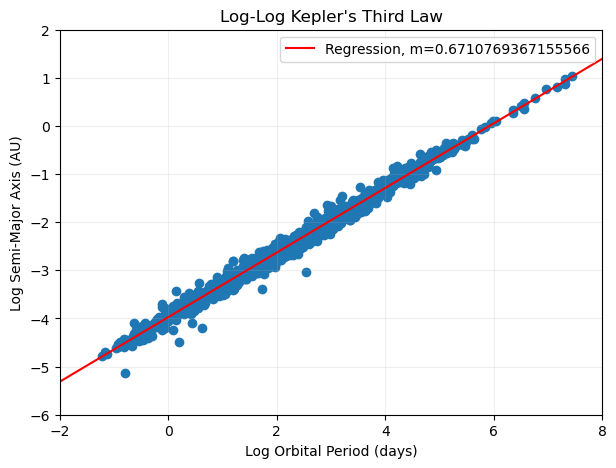

In [348]:
def regression(result, rng=[-50, 50]):
    # y = ax + b
    a = result.slope
    b = result.intercept
    x = np.linspace(rng[0], rng[1], 100)
    return x, a*x + b 

plt.figure(figsize=(7, 5))
plt.scatter(T_prime, a_prime)
plt.xlabel('Log Orbital Period (days)')
plt.ylabel('Log Semi-Major Axis (AU)')
plt.title("Log-Log Kepler's Third Law")
plt.xlim(-2, 8)
plt.ylim(-6, 2)
plt.grid(alpha=0.2)

x, y = regression(result)
plt.plot(x, y, color='red', label='Regression, m={}'.format(result.slope))
plt.legend()
plt.show()

Look at how beautifully this matches the dataset. We can also revert this back to a power law and see how it matches the original data.

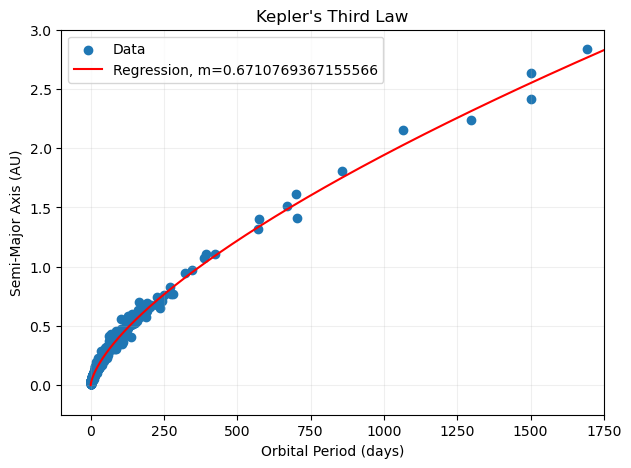

In [399]:
mask = df['koi_period'] < 20000

plt.figure(figsize=(7, 5))
plt.scatter(df['koi_period'][mask], df['koi_sma'][mask], label='Data') # notice the new mask applied
plt.grid(alpha = .2)
plt.xlabel('Orbital Period (days)')
plt.ylabel('Semi-Major Axis (AU)')
plt.title("Kepler's Third Law")

x_nonlog = np.linspace(0, 1750, 10000)
y_nonlog = (np.e**result.intercept) * x_nonlog**result.slope
plt.plot(x_nonlog, y_nonlog, color='red', label='Regression, m={}'.format(result.slope))
plt.xlim(-100, 1750)
plt.ylim(-0.25, 3)
plt.legend()
plt.show()

There you have it. Kepler's Third Law in action. Notice how closely our regression value of ~0.67 matches 2/3. 

I really like this example for many reasons. Not only did we use all 4 of the major packages we have discussed in these lectures, but it also took some physics and statistical reasoning on a real dataset. I don't know about you, but I find it quite beautiful that Kepler's Third Law, which Kepler discovered here on earth, holds for exoplanets farther than our eyes will ever see.

## Sic Itur Ad Astra - "Such is the Way to the Stars"

Whew, that was a lot. Take a second to appreciate the task we just accomplished. We truly solved a real scientific problem today, and I'd like to think that makes us one step closer to touching the stars. 